In [1]:
import torch
import torch_geometric
from torch_geometric import utils
from torch_geometric.nn import SAGEConv
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from scipy.sparse import coo_matrix
import pandas as pd
import numpy as np
import random

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [2]:
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [3]:
ec_hic = np.load('../data/ec_adj_mat_t25.npy')
hsr_hic = np.load('../data/hsr_adj_mat_t25.npy')

ec_df = pd.read_csv('../data/ec_cleaned.csv')
hsr_df = pd.read_csv('../data/hsr_cleaned.csv')

hsr_feats = torch.tensor(hsr_df[['read_count', 'total_genes']].to_numpy())
hsr_labels = torch.zeros(hsr_feats.shape[0])

ec_feats = torch.tensor(ec_df[['read_count', 'total_genes']].to_numpy())
ec_labels = torch.ones(ec_feats.shape[0])

def hic_to_sparse(hic_mat):
    adj_mat = np.triu(hic_mat)
    sparse_adj = coo_matrix(adj_mat)

    return utils.from_scipy_sparse_matrix(sparse_adj)

hsr_edge_index, hsr_edge_attr = hic_to_sparse(hsr_hic)
hsr_graph = torch_geometric.data.Data(edge_index = hsr_edge_index, edge_attr = hsr_edge_attr, x = hsr_feats, y = hsr_labels)

ec_edge_index, ec_edge_attr = hic_to_sparse(ec_hic)
ec_graph = torch_geometric.data.Data(edge_index = ec_edge_index, edge_attr = ec_edge_attr, x = ec_feats, y = ec_labels)

x = torch.cat([ec_feats, hsr_feats], dim=0)
hsr_edge_index = hsr_edge_index + ec_labels.shape[0]
edge_index = torch.cat([ec_edge_index, hsr_edge_index], dim=1)
edge_attr = torch.cat([ec_edge_attr, hsr_edge_attr], dim=0)
labels = torch.cat([ec_labels, hsr_labels], dim=0)

G = torch_geometric.data.Data(edge_index = edge_index, edge_attr = edge_attr, x = x, y = labels)

In [4]:
class GraphSAGE(nn.Module):
    def __init__(self, num_feat, num_graph_conv_layers, graph_conv_layer_sizes, num_lin_layers, lin_hidden_sizes, num_classes):
        super().__init__()
        self.num_graph_conv_layers = num_graph_conv_layers
        self.num_lin_layers = num_lin_layers
        self.embeddings = None

        if self.num_graph_conv_layers == 1:
            self.conv1 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])
        elif self.num_graph_conv_layers == 2:
            self.conv1 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])
            self.conv2 = SAGEConv(graph_conv_layer_sizes[1], graph_conv_layer_sizes[2])
        elif self.num_graph_conv_layers == 3:
            self.conv1 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])
            self.conv2 = SAGEConv(graph_conv_layer_sizes[1], graph_conv_layer_sizes[2])
            self.conv3 = SAGEConv(graph_conv_layer_sizes[2], graph_conv_layer_sizes[3])
        
        if self.num_lin_layers == 1:
            self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
        elif self.num_lin_layers == 2:
            self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
            self.lin2 = nn.Linear(lin_hidden_sizes[1], lin_hidden_sizes[2])
        elif self.num_lin_layers == 3:
            self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
            self.lin2 = nn.Linear(lin_hidden_sizes[1], lin_hidden_sizes[2])
            self.lin3 = nn.Linear(lin_hidden_sizes[2], lin_hidden_sizes[3])
            
        self.loss_calc = nn.CrossEntropyLoss()
        self.torch_softmax = nn.Softmax(dim=1)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        ### Graph convolution module
        if self.num_graph_conv_layers == 1:
            h = self.conv1(x, edge_index)
            h = torch.relu(h)
        elif self.num_graph_conv_layers == 2:
            h = self.conv1(x, edge_index)
            h = torch.relu(h)
            h = self.conv2(h, edge_index)
            h = torch.relu(h)
        elif self.num_graph_conv_layers == 3:
            h = self.conv1(x, edge_index)
            h = torch.relu(h)
            h = self.conv2(h, edge_index)
            h = torch.relu(h)
            h = self.conv3(h, edge_index)
            h = torch.relu(h)
            
        #h = F.dropout(h, p = self.dropout_value)
        self.embeddings = h
        scores = h
        ### Linear module
        if self.num_lin_layers == 0:
            return scores
        elif self.num_lin_layers == 1:
            scores = self.lin1(scores)
        elif self.num_lin_layers == 2:
            scores = self.lin1(scores)
            scores = torch.relu(scores)
            scores = self.lin2(scores)
        elif self.num_lin_layers == 3:
            scores = self.lin1(scores)
            scores = torch.relu(scores)
            scores = self.lin2(scores)
            scores = torch.relu(scores)
            scores = self.lin3(scores)
        
        return scores

    def loss(self, scores, labels):
        xent_loss = self.loss_calc(scores, labels)
        return xent_loss
    
    def calc_softmax_pred(self, scores):
        softmax = self.torch_softmax(scores)
        predicted = torch.argmax(softmax, 1)
        return softmax, predicted

    def get_embeddings(self):
        if self.embeddings is not None:
            return self.embeddings

        print("Untrained Model: Please train model first")
        return None

In [5]:
# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
# separate train/test sets
def split_data(G, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert train_ratio + val_ratio + test_ratio == 1, "Ratios must sum to 1."
    
    torch.manual_seed(seed)
    num_nodes = G.x.shape[0]  # Total number of nodes
    indices = torch.randperm(num_nodes)  # Shuffle node indices randomly
    
    train_size = int(train_ratio * num_nodes)
    val_size = int(val_ratio * num_nodes)
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:]

    # Create boolean masks
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    # Attach masks to the graph
    G.train_mask = train_mask
    G.val_mask = val_mask
    G.test_mask = test_mask

    return G

In [7]:
# build train function with train/test split, build test function - condensed
# implement early stopping
def train(model, optimizer, graph, device):
    model.train()
    optimizer.zero_grad()
    scores = model(graph)
    loss = model.loss(scores[graph.train_mask], graph.y[graph.train_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item(), scores

def test(model, graph, device):
    model.eval()
    scores = model(graph)
    softmax, predicted = model.calc_softmax_pred(scores)
    accs = []
    losses = []
    
    for mask in [graph.train_mask, graph.val_mask, graph.test_mask]:
        loss = model.loss(scores[mask], graph.y[mask]).item()
        correct = (predicted[mask] == graph.y[mask]).sum().item()
        acc = correct / mask.sum().item()
        accs.append(acc)
        losses.append(loss)
    
    return accs, losses

In [8]:
# Model inputs + layer information
num_features = G.num_node_features
num_graph_sage_layers = 2
num_classes = 2
graph_sage_layer_sizes = [num_features,8,16]
linear_layer_sizes = [16,8,num_classes]
num_linear_layers = 2

# Hyperparameters
learning_rate = 0.005
weight_decay = 5e-4
num_epochs = 10000
patience = 500  # Number of epochs with no improvement before stopping
min_delta = 0.03  # Minimum change to qualify as an improvement

# Initialize the model, optimizer, and send to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphSAGE(num_features, num_graph_sage_layers, graph_sage_layer_sizes, num_linear_layers, linear_layer_sizes, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# add to graphsage.py if works
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience//2, verbose=True) #Reduces LR by 50% when training plateaus

# Assign train and test masks to graph
G.x = G.x.float()
G.y = G.y.long()
G = split_data(G)
G = G.to(device)

In [45]:
#runs = []
#for _ in range(100):
model = GraphSAGE(num_features, num_graph_sage_layers, graph_sage_layer_sizes, num_linear_layers, linear_layer_sizes, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
#scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience//2, verbose=True) #Reduces LR by 50% when training plateaus

# Assign train and test masks to graph
G = torch_geometric.data.Data(edge_index = edge_index, edge_attr = edge_attr, x = x, y = labels)
G.x = G.x.float()
G.y = G.y.long()
G = split_data(G)
G = G.to(device)

train_accs = []
val_accs = []
test_accs = []
losses = []

best_val_acc = float('-inf')
patience_counter = 0

best_model = None

for epoch in range(1, num_epochs + 1):
    loss, score = train(model, optimizer, G, device)
    (train_acc, val_acc, test_acc), (train_loss, val_loss, test_loss) = test(model, G, device)

    # Track metrics
    losses.append(loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    test_accs.append(test_acc)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Early stopping check - only start checking after 3000 epochs
    if epoch >= 5000:
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            final_test_acc = test_acc
            
            patience_counter = 0
            best_model = model.state_dict()  # Save best model
        elif val_acc > best_val_acc - min_delta:
            pass
        else:
            patience_counter += 1

        # Adjust learning rate
        #scheduler.step(val_loss)

        #if epoch == 5000 and patience_counter < patience:
            #runs.append([train_accs[-1], test_accs[-1]])
            
        # Stop if validation loss doesn't improve for 'patience' epochs
        if patience_counter >= patience:
            print()
            print(f"Early stopping triggered at epoch {epoch}. Val acc: {val_accs[-1]:.4f}, Test acc: {test_accs[-1]:.4f}")
            print(f"Best Val Acc: {best_val_acc:.4f}, Final Test Acc: {(final_test_acc + best_val_acc) / 2:.4f}")
            #runs.append([train_accs[-100], test_accs[-100]])
            break

Epoch 100, Loss: 0.8092, Val Acc: 0.6400, Test Acc: 0.5263
Epoch 200, Loss: 0.8650, Val Acc: 0.5867, Test Acc: 0.6316
Epoch 300, Loss: 0.6799, Val Acc: 0.6667, Test Acc: 0.6842
Epoch 400, Loss: 0.4912, Val Acc: 0.6667, Test Acc: 0.6842
Epoch 500, Loss: 0.5115, Val Acc: 0.6667, Test Acc: 0.6316
Epoch 600, Loss: 0.6414, Val Acc: 0.6533, Test Acc: 0.6316
Epoch 700, Loss: 0.5737, Val Acc: 0.5867, Test Acc: 0.6316
Epoch 800, Loss: 0.4807, Val Acc: 0.7333, Test Acc: 0.6842
Epoch 900, Loss: 0.4244, Val Acc: 0.7067, Test Acc: 0.6711
Epoch 1000, Loss: 0.3888, Val Acc: 0.7333, Test Acc: 0.6974
Epoch 1100, Loss: 0.3590, Val Acc: 0.7200, Test Acc: 0.7105
Epoch 1200, Loss: 0.3286, Val Acc: 0.7067, Test Acc: 0.7237
Epoch 1300, Loss: 0.4232, Val Acc: 0.7200, Test Acc: 0.7105
Epoch 1400, Loss: 0.4140, Val Acc: 0.7067, Test Acc: 0.7105
Epoch 1500, Loss: 0.2886, Val Acc: 0.6800, Test Acc: 0.7368
Epoch 1600, Loss: 0.2776, Val Acc: 0.6933, Test Acc: 0.7368
Epoch 1700, Loss: 0.2679, Val Acc: 0.7067, Test A

In [52]:
final_test_accs = []
all_accs = {}
for j in range(10):
    model = GraphSAGE(num_features, num_graph_sage_layers, graph_sage_layer_sizes, num_linear_layers, linear_layer_sizes, num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    G = torch_geometric.data.Data(edge_index = edge_index, edge_attr = edge_attr, x = x, y = labels)
    G.x = G.x.float()
    G.y = G.y.long()
    G = split_data(G)
    G = G.to(device)
    
    val_accs = []
    test_accs = []
    
    best_val_acc = float('-inf')
    final_test_acc = None
    patience_counter = 0
    
    best_model = None
    last_epoch = None
    
    for epoch in range(1, num_epochs + 1):
        loss, score = train(model, optimizer, G, device)
        (train_acc, val_acc, test_acc), (train_loss, val_loss, test_loss) = test(model, G, device)
    
        val_accs.append(val_acc)
        test_accs.append(test_acc)
    
        if epoch >= 5000:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                final_test_acc = test_acc
                
                patience_counter = 0
                best_model = model.state_dict()
            elif val_acc > best_val_acc - min_delta:
                pass
            else:
                patience_counter += 1

            if patience_counter >= patience:
                last_epoch = epoch
                break

    final_test_accs.append((final_test_acc + best_val_acc) / 2)
    last_epoch = 10000 if last_epoch is None else last_epoch

    if final_test_accs[-1] < 0.75:
        all_accs[j] = val_accs
    
    print(f'Run {j+1} ended with final test accuracy {final_test_accs[-1]} at Epoch {last_epoch}')

Run 1 ended with final test accuracy 0.7417543859649123 at Epoch 6001
Run 2 ended with final test accuracy 0.8278070175438597 at Epoch 6314
Run 3 ended with final test accuracy 0.7816666666666667 at Epoch 5750
Run 4 ended with final test accuracy 0.8078947368421052 at Epoch 6530
Run 5 ended with final test accuracy 0.8609649122807017 at Epoch 6063
Run 6 ended with final test accuracy 0.8279824561403509 at Epoch 6070
Run 7 ended with final test accuracy 0.8080701754385965 at Epoch 6848
Run 8 ended with final test accuracy 0.834561403508772 at Epoch 5899
Run 9 ended with final test accuracy 0.7946491228070176 at Epoch 6113
Run 10 ended with final test accuracy 0.8279824561403509 at Epoch 5642


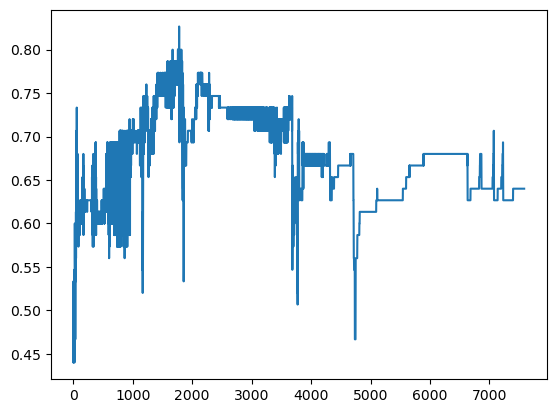

In [51]:
plt.plot(all_accs[8])

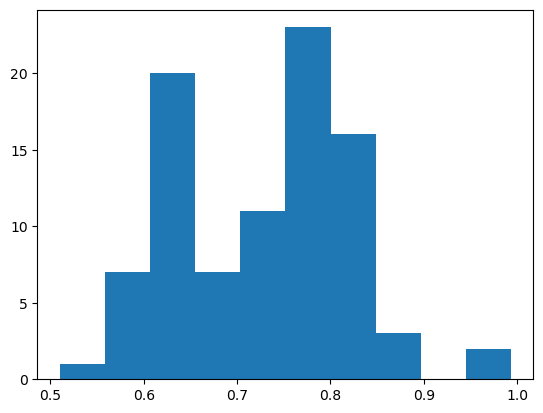

In [14]:
plt.hist(final_test_accs)
plt.show()